# Introduction

I am exporting the data from ESB website. It has 3 options:
- 30 min reading in KWh
- Daily snapshot of day/night/peak usage - accumulative data
- Daily snapshot of todal usage and export data - accumulative data

In this report I will be analyzing the 30 min reading since it is easy to review. The document they provide is a csv format.
it contains this columns:
- MPRN (i will remove)
- METER SERIAL NUMBER (i will remove)
- READ VALUE - 4.2360
- READ TYPE - Active Export Interval (kWh) OR Active Import Interval (kWh)
- READ DATE AND END TIME - 09-11-2025 02:30

## Import Statements

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Alignment

## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format
plt.style.available
plt.style.use("seaborn-v0_8")
month_report = "October"
output_file_name=f"ESB Monthly Report_{month_report}.xls"

## Load the Data

In [3]:
#the main fail contains information from 2023 so we need a way to filter the main source
def filter_by_date_range(df, start=None, end=None):
    if start:
        df = df[df["Read Date and End Time"] >= pd.to_datetime(start)]
    if end:
        df = df[df["Read Date and End Time"] <= pd.to_datetime(end)]
    return df.copy()

In [4]:
data = pd.read_csv("HDF_calckWh_10004808230_10-11-2025.csv").drop(columns=["MPRN","Meter Serial Number"])

# Parse datetime and sort
data["Read Date and End Time"] = pd.to_datetime(data["Read Date and End Time"], format="%d-%m-%Y %H:%M")
data = filter_by_date_range(data, "2025-09-08", "2025-11-07")
data = data.sort_values("Read Date and End Time")

# Rename columns for clarity
data.rename(columns={"Read Value": "kWh", "Read Date and End Time": "Datetime"}, inplace=True)

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
#SHAPE OF DATAFRAMES
shape_data = data.shape

print(f"** Dataframe has {shape_data[0]} rows and {shape_data[1]} columns")
print(f"** List of columns {data.columns.values}")
#Descriptip information, info, describe, head, nunique values, ...
data.head()

** Dataframe has 5038 rows and 3 columns
** List of columns ['kWh' 'Read Type' 'Datetime']


,kWh,Read Type,Datetime
5239,0.20,Active Import Interval (kWh),2025-09-08 00:00:00
5238,0.08,Active Import Interval (kWh),2025-09-08 00:30:00
5237,0.06,Active Import Interval (kWh),2025-09-08 01:00:00
5236,0.07,Active Import Interval (kWh),2025-09-08 01:30:00
5235,0.10,Active Import Interval (kWh),2025-09-08 02:00:00


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5038 entries, 5239 to 202
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   kWh        5038 non-null   float64       
 1   Read Type  5038 non-null   object        
 2   Datetime   5038 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 157.4+ KB


In [7]:
data.describe()

,kWh,Datetime
count,"5,038.00",5038
mean,0.22,2025-10-11 06:07:19.460103168
min,0.00,2025-09-08 00:00:00
25%,0.00,2025-09-28 16:37:30
50%,0.01,2025-10-11 19:30:00
75%,0.18,2025-10-24 22:22:30
max,5.86,2025-11-07 00:00:00
std,0.68,NaN


## 1. Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values.

In [8]:
#NAN values - there is only one row with NAN values
print(f"* Does data has empty values: {data.isna().values.any()}")
print(f"\n* Data has empty values in the following columns:\n{data.isna().sum()}")
print(f"\n* Total empty values in data: {data.isna().sum().sum()}")

* Does data has empty values: False

* Data has empty values in the following columns:
kWh          0
Read Type    0
Datetime     0
dtype: int64

* Total empty values in data: 0


## 2. Data Cleaning - Check for Duplicates

In [9]:
#DUPLICATE VALUES

print(f"Does data has duplicate values: {data.duplicated().values.any()}")
print(f"Total Duplicated: {data.duplicated().value_counts()}")

Does data has duplicate values: True
Total Duplicated: False    5037
True        1
Name: count, dtype: int64


## 3. Data Cleaning - Convert Data Types
check for datetimes, int, floating, category ... using astype or pd.to_dateformat

In [10]:
#there are 2 columns that coulc be converted into categories - > Undergraduate Major and Group
data.dtypes

kWh                 float64
Read Type            object
Datetime     datetime64[ns]
dtype: object

# Data Analysis

### Calculate key indicators

In [11]:
# filters imported energy and exported 
f_imported_data = data["Read Type"] == "Active Import Interval (kWh)"
f_exported_data = data["Read Type"] == "Active Export Interval (kWh)"

In [12]:
# ==============================
# Define Tariff Periods (Night: 02:00–06:00)
# ==============================
# Real rates in euro per kWh
night_rate = 0.089
day_rate = 0.3793
#how much is paying the goverment now 0.185€ per KWh
current_selling_rate = 0.185 # €/kWh exported

data["Hour"] = data["Datetime"].dt.hour
data["Tariff"] = data["Hour"].apply(lambda h: "Night" if 2 <= h < 6 else "Day")
data["Cost"] = data[f_imported_data].apply(lambda row: row["kWh"] * night_rate if row["Tariff"] == "Night" else row["kWh"] * day_rate, axis=1)
#for exported data the cost is 0 so we need to fill the Cost to 0
data["Cost"]=data["Cost"].fillna(0)

#for exported we will collect the info in column Revenue_€
data["Revenue_€"] = data[f_exported_data]["kWh"]* current_selling_rate
data["Revenue_€"] = data["Revenue_€"].fillna(0)
data["Month"] = data["Datetime"].dt.to_period("M")



In [13]:
data[f_exported_data]

,kWh,Read Type,Datetime,Hour,Tariff,Cost,Revenue_€,Month
4511,0.00,Active Export Interval (kWh),2025-09-23 04:00:00,4,Night,0.00,0.00,2025-09
4508,0.00,Active Export Interval (kWh),2025-09-23 04:30:00,4,Night,0.00,0.00,2025-09
4506,0.00,Active Export Interval (kWh),2025-09-23 05:00:00,5,Night,0.00,0.00,2025-09
4504,0.00,Active Export Interval (kWh),2025-09-23 05:30:00,5,Night,0.00,0.00,2025-09
4502,0.00,Active Export Interval (kWh),2025-09-23 06:00:00,6,Day,0.00,0.00,2025-09
...,...,...,...,...,...,...,...,...
211,0.00,Active Export Interval (kWh),2025-11-06 22:00:00,22,Day,0.00,0.00,2025-11
209,0.00,Active Export Interval (kWh),2025-11-06 22:30:00,22,Day,0.00,0.00,2025-11
207,0.00,Active Export Interval (kWh),2025-11-06 23:00:00,23,Day,0.00,0.00,2025-11
204,0.00,Active Export Interval (kWh),2025-11-06 23:30:00,23,Day,0.00,0.00,2025-11


### 1 - Daily Summary

In [14]:
#daily exported summary
groupby_daily_exported = data[f_exported_data].groupby(data["Datetime"].dt.date)

In [15]:
#daily_summary = groupby_daily_imported.agg({"kWh":"sum", "Cost":"sum"})
daily_summary_exported = groupby_daily_exported.agg(
    Total_kWh_Exported=("kWh", "sum"),
    Total_Revenue_Exported=("Revenue_€", "sum")
)
daily_summary_exported.sum()

Total_kWh_Exported       46.69
Total_Revenue_Exported    8.64
dtype: float64

In [16]:
daily_summary = data[f_imported_data].pivot_table(values="kWh", aggfunc="sum", index=data["Datetime"].dt.date, columns="Tariff").fillna(0)

In [17]:
daily_summary["Total_kWh"] = daily_summary["Day"] + daily_summary["Night"]
daily_summary["Night_kWh_%"] = (daily_summary["Night"] / daily_summary["Total_kWh"]*100).round(1)
daily_summary["Day_kWh_%"] = (daily_summary["Day"] / daily_summary["Total_kWh"]*100).round(1)
daily_summary["Cost_Day"] = daily_summary["Day"] * day_rate
daily_summary["Cost_Night"] = daily_summary["Night"] * night_rate
daily_summary["Total_Cost"] = daily_summary["Cost_Day"] + daily_summary["Cost_Night"]

daily_summary.rename(columns={"Day": "Day_kWh", "Night": "Night_kWh"}, inplace=True)

In [18]:
#daily imported summary

In [19]:
daily_summary

Tariff,Day_kWh,Night_kWh,Total_kWh,Night_kWh_%,Day_kWh_%,Cost_Day,Cost_Night,Total_Cost
Datetime,,,,,,,,
2025-09-08,6.97,2.80,9.77,28.70,71.30,2.64,0.25,2.89
2025-09-09,11.89,27.24,39.13,69.60,30.40,4.51,2.42,6.93
2025-09-10,8.94,22.68,31.62,71.70,28.30,3.39,2.02,5.41
2025-09-11,12.03,25.56,37.59,68.00,32.00,4.56,2.28,6.84
2025-09-12,7.83,3.47,11.30,30.70,69.30,2.97,0.31,3.28
...,...,...,...,...,...,...,...,...
2025-11-03,6.07,31.22,37.29,83.70,16.30,2.30,2.78,5.08
2025-11-04,1.92,6.15,8.07,76.20,23.80,0.73,0.55,1.28
2025-11-05,1.44,7.37,8.81,83.70,16.30,0.55,0.66,1.20


### 2 - Monthly summary

In [20]:
### 2 - Monthly Summary exported and imported

In [21]:
#monthly imported
montly_summary = data[f_imported_data].pivot_table(values="kWh", aggfunc="sum", index=data["Month"], columns="Tariff").fillna(0)

In [22]:
montly_summary["Total_kWh"] = montly_summary["Day"] + montly_summary["Night"]
montly_summary["Night_kWh_%"] = (montly_summary["Night"] / montly_summary["Total_kWh"]*100).round(1)
montly_summary["Day_kWh_%"] = (montly_summary["Day"] / montly_summary["Total_kWh"]*100).round(1)
montly_summary["Cost_Day"] = montly_summary["Day"] * day_rate
montly_summary["Cost_Night"] = montly_summary["Night"] * night_rate
montly_summary["Total_Cost"] = montly_summary["Cost_Day"] + montly_summary["Cost_Night"]

montly_summary.rename(columns={"Day": "Day_kWh", "Night": "Night_kWh"}, inplace=True)

In [23]:
montly_summary

Tariff,Day_kWh,Night_kWh,Total_kWh,Night_kWh_%,Day_kWh_%,Cost_Day,Cost_Night,Total_Cost
Month,,,,,,,,
2025-09,214.01,212.21,426.23,49.80,50.20,81.18,18.89,100.06
2025-10,191.16,375.52,566.68,66.30,33.70,72.51,33.42,105.93
2025-11,12.43,63.55,75.98,83.60,16.40,4.72,5.66,10.37


In [24]:
#monthly exported summary
groupby_monthly_exported = data[f_exported_data].groupby(data["Month"])

In [25]:
monthly_summary_exported = groupby_monthly_exported.agg(
    Total_kWh=("kWh", "sum"),
    Total_Revenue_Exported=("Revenue_€", "sum")
)
monthly_summary_exported

,Total_kWh,Total_Revenue_Exported
Month,,
2025-09,0.00,0.00
2025-10,34.26,6.34
2025-11,12.42,2.30


### 3 - Visualizations

In [26]:
# ==============================
# Visualizations
# ==============================

In [27]:
#Daily Energy Split: Day vs Night" bar char

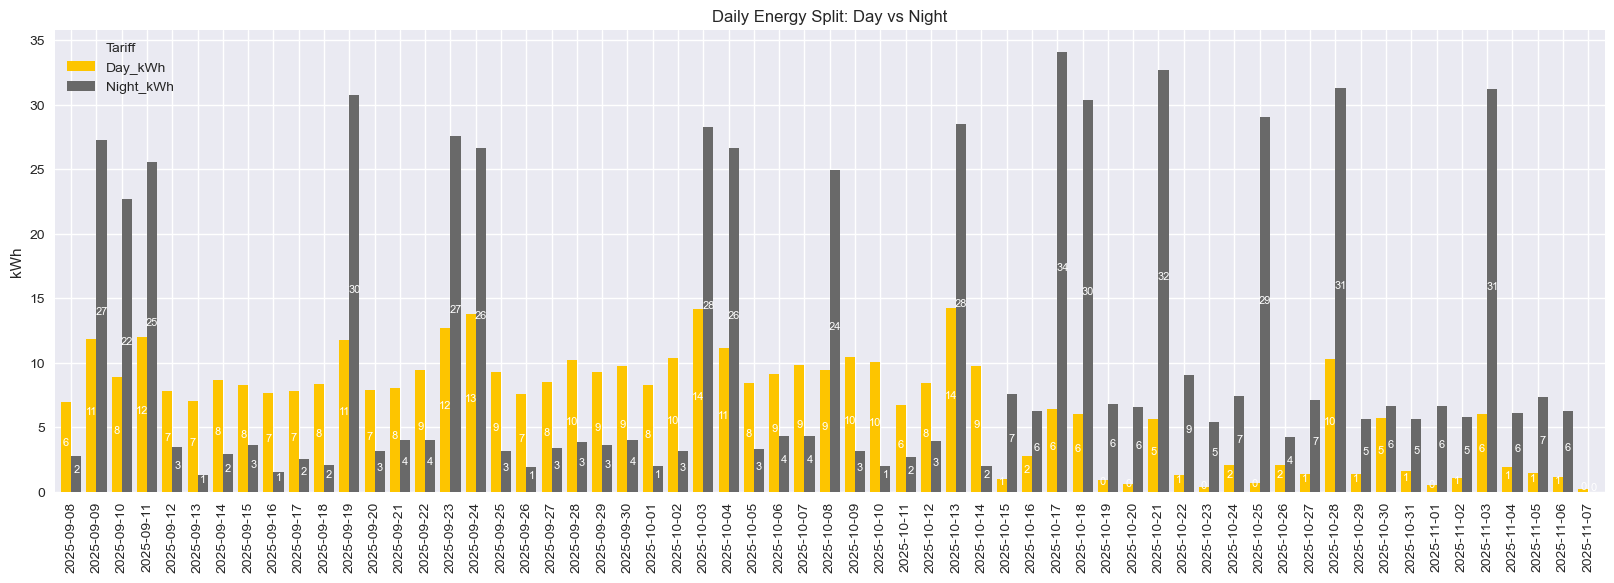

In [28]:
fig1 = daily_summary.plot(y=["Day_kWh","Night_kWh"], kind="bar", width=0.8, xlabel="", ylabel="kWh", title="Daily Energy Split: Day vs Night", figsize=(20,6), color=["#fdc500", "#696969"])

for container in fig1.containers:
    fig1.bar_label(container, fmt="%d", label_type="center", padding=3, fontsize=8, color="white")

### 4 - Export files

In [29]:
daily_summary

Tariff,Day_kWh,Night_kWh,Total_kWh,Night_kWh_%,Day_kWh_%,Cost_Day,Cost_Night,Total_Cost
Datetime,,,,,,,,
2025-09-08,6.97,2.80,9.77,28.70,71.30,2.64,0.25,2.89
2025-09-09,11.89,27.24,39.13,69.60,30.40,4.51,2.42,6.93
2025-09-10,8.94,22.68,31.62,71.70,28.30,3.39,2.02,5.41
2025-09-11,12.03,25.56,37.59,68.00,32.00,4.56,2.28,6.84
2025-09-12,7.83,3.47,11.30,30.70,69.30,2.97,0.31,3.28
...,...,...,...,...,...,...,...,...
2025-11-03,6.07,31.22,37.29,83.70,16.30,2.30,2.78,5.08
2025-11-04,1.92,6.15,8.07,76.20,23.80,0.73,0.55,1.28
2025-11-05,1.44,7.37,8.81,83.70,16.30,0.55,0.66,1.20
